In [1]:
## Peizhi Yan 2025 Copyright.

"""
In this demo we train a simple GPT on a small dataset of Shakespeare's sonnets.

References:
 - Attention is All You Need: https://arxiv.org/abs/1706.03762
 - https://colab.research.google.com/drive/1JMLa53HDuA-i7ZBmqV7ZnA3c_fvtXnx-?usp=sharing#scrollTo=Q3k1Czf7LuA9
"""
import os
import torch
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
from time import time
from tqdm import tqdm
from IPython.display import clear_output  # for Jupyter, or use plt.pause in scripts

from gpt_utils import PositionalEncoding, SimpleTokenizer
from gpt_lite import GPT

# device = 'cpu'
# select the device to run the model (priority: cuda > mps > cpu)
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Computing Device: ', device)

# define some hyperparameters
BATCH_SIZE = 16
MAX_LENGTH = 60     # the maximum amount of "tokens" in a sequence
DIMENSION = 64      # the dimension of each "token" embedding
ATTN_HEADS = 8      # the number of attention heads
NUM_BLOCKS = 6      # the number of transformer encoder/decoder blocks


Computing Device:  mps


### Visualize Positional Encoding

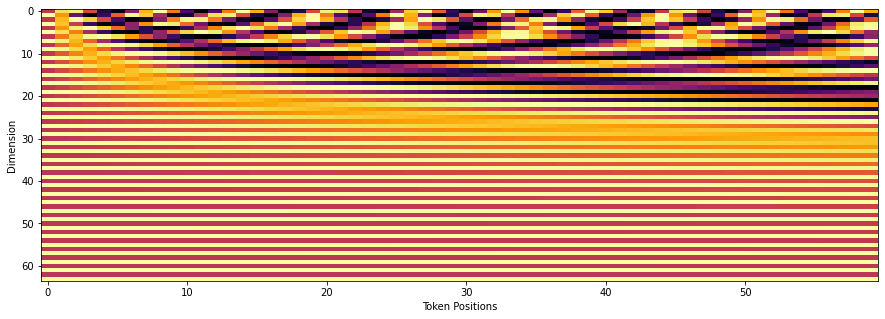

In [2]:
PE = PositionalEncoding(max_length=MAX_LENGTH, dim=DIMENSION, device=device)
x = torch.zeros([1, MAX_LENGTH, DIMENSION]).to(device) # batch = 1, sequence length = 100
x_pe = PE(x)
plt.figure(figsize=(15,5))
plt.imshow(x_pe[0].T.cpu(), cmap='inferno', aspect='auto', interpolation='none')
plt.xlabel('Token Positions'); plt.ylabel('Dimension')
plt.show()


### Data, Tokenization, Embedding Module

Length of dataset (characters): 1075390
All unique chars:  !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
Tokens:  ['F', 'i', 'r', 's', 't', ' ', 'C', 'i', 't', 'i', 'z', 'e', 'n', ':', 'B', 'e', 'f', 'o', 'r', 'e', ' ', 'w', 'e', ' ', 'p', 'r', 'o', 'c', 'e', 'e', 'd', ' ', 'a', 'n', 'y', ' ', 'f', 'u', 'r', 't', 'h', 'e', 'r', ',', ' ', 'h', 'e', 'a', 'r', ' ', 'm', 'e', ' ', 's', 'p', 'e', 'a', 'k', '.', 'A']
Text reconstructed from tokens:  First Citizen:Before we proceed any further, hear me speak.A
torch.Size([1, 60, 64])


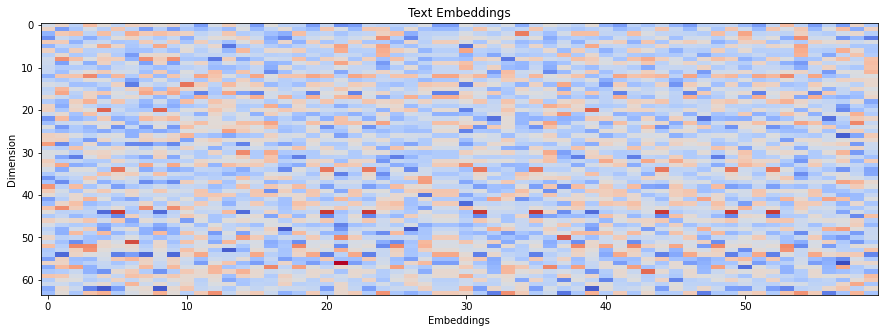

In [3]:
# load the data
texts = []
data_path = './data/tinyshakespeare.txt'
with open(data_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip() # remove leading/trailing spaces
        if len(line) > 0:
            texts.append(line)
data = "".join(texts) # join the lines into one long string as the dataset

# print some statistics about the dataset
chars = sorted(list(set(data))) # get the unique characters in the text
print("Length of dataset (characters):", len(data))
print("All unique chars:", ''.join(chars))

# create a simple tokenizer from the corpus
tokenizer = SimpleTokenizer(texts=data, max_length=MAX_LENGTH)

# test the tokenizer
indices = tokenizer.get_indices(text=data[:60])      # tokenize the text and get indices
tokens = tokenizer.get_tokens(indices=indices)       # convert the indices back to tokens
print("Tokens: ", tokens)
print("Text reconstructed from tokens: ", tokenizer.get_text_from_tokens(tokens=tokens)) # convert the list of tokens to text

# create embedding module
padding_idx = tokenizer.token_to_index['<EMPTY>']
num_embeddings = tokenizer.num_tokens # get the vocabulary size
token_embeder = torch.nn.Embedding(num_embeddings=num_embeddings, embedding_dim=DIMENSION, 
                                   padding_idx=padding_idx, device=device)

# test token embedding
embeddings = token_embeder(torch.LongTensor([indices]).to(device)) # get the token embeddings
print(embeddings.shape)
plt.figure(figsize=(15,5))
plt.imshow(embeddings[0, :, :].detach().T.cpu(), cmap='coolwarm', aspect='auto', interpolation='none')
plt.title('Text Embeddings'); plt.xlabel('Embeddings'); plt.ylabel('Dimension')
plt.show()


In [4]:
data_token_indices = tokenizer.get_indices(text=data)      # tokenize the entire dataset and get indices
print('Total tokens in dataset: ', len(data_token_indices)) # print the length of the dataset

def get_random_batch(data_token_indices, batch_size, block_size, device):
    """
    generate a random batch of data of inputs x and targets y
    y is shifted by one position to the right, so that the model can learn to predict the next token
    inputs:
        - data_token_indices: list of token indices of the entire dataset
        - batch_size: the number of sequences in a batch (N)
        - block_size: the maximum sub-sequence length (L)
        - device: the device to run the model on
    outputs:
        - x: input sequences [batch_size, block_size]
        - y: target sequences [batch_size, block_size]
    """
    rand_ix = np.random.random_integers(0, len(data_token_indices) - block_size, batch_size) # generate random starting indices
    batch_x = [data_token_indices[i:i + block_size] for i in rand_ix]         # get the input sequences   [N, L]
    batch_y = [data_token_indices[i + 1:i + block_size + 1] for i in rand_ix] # get the target sequences  [N, L]
    # convert to tensors
    batch_x = torch.LongTensor(batch_x).to(device) # convert to LongTensor
    batch_y = torch.LongTensor(batch_y).to(device) # convert to LongTensor
    return batch_x, batch_y

# test the function
batch_size = 4
block_size = 8
batch_x, batch_y = get_random_batch(data_token_indices, batch_size, block_size, device) # test the function
print('inputs:')
print(batch_x.shape)
print(batch_x)
print('targets:')
print(batch_y.shape)
print(batch_y)


Total tokens in dataset:  1075390
inputs:
torch.Size([4, 8])
tensor([[ 6,  5, 12,  7, 14,  9, 18, 25],
        [52, 12,  6,  9, 25, 12, 22,  6],
        [20, 28,  9, 20, 17, 13, 34, 12],
        [ 9,  7, 25, 22, 31, 31,  9, 25]], device='mps:0')
targets:
torch.Size([4, 8])
tensor([[ 5, 12,  7, 14,  9, 18, 25, 12],
        [12,  6,  9, 25, 12, 22,  6,  8],
        [28,  9, 20, 17, 13, 34, 12, 23],
        [ 7, 25, 22, 31, 31,  9, 25, 12]], device='mps:0')


/var/folders/sq/104fglwd4sq6tzg4hwc_h70c0000gn/T/ipykernel_93251/978170808.py:17: DeprecationWarning: This function is deprecated. Please call randint(0, 1075382 + 1) instead
  rand_ix = np.random.random_integers(0, len(data_token_indices) - block_size, batch_size) # generate random starting indices


### Create Model

In [5]:
# get the vocabulary size (represented by the number of possible tokens in the dictionary)
VOCABULARY_SIZE = tokenizer.num_tokens

# create the transformer model
gpt = GPT(dim=DIMENSION, num_heads=ATTN_HEADS, num_blocks=NUM_BLOCKS, 
          max_length=MAX_LENGTH, vocabulary_size=VOCABULARY_SIZE, device=device)

# optional: compile the model to optimize the performance, needs torch 2.0 or above
if os.name == 'nt':
    # torch.compile() is not supported on Windows (nt) yet
    print('torch.compile() is not supported on Windows yet, please use Linux or MacOS')
else:
    gpt = torch.compile(gpt)

gpt.train()

print(gpt)
print(sum(p.numel() for p in gpt.parameters())/1e6, 'M parameters')


OptimizedModule(
  (_orig_mod): GPT(
    (positional_encoding): PositionalEncoding()
    (gpt_blocks): ModuleList(
      (0-5): 6 x GPTBlock(
        (self_attn): MultiHeadAttention(
          (Wq): Linear(in_features=64, out_features=64, bias=False)
          (Wk): Linear(in_features=64, out_features=64, bias=False)
          (Wv): Linear(in_features=64, out_features=64, bias=False)
          (out): Linear(in_features=64, out_features=64, bias=False)
        )
        (ln1): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
        (ln2): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
        (ffn): FeedForwardNetwork(
          (fc1): Linear(in_features=64, out_features=64, bias=True)
          (fc2): Linear(in_features=64, out_features=64, bias=True)
        )
      )
    )
    (output_layer): Linear(in_features=64, out_features=68, bias=True)
  )
)
0.15418 M parameters


### Train

Note: this code assumes the batch size is one. 

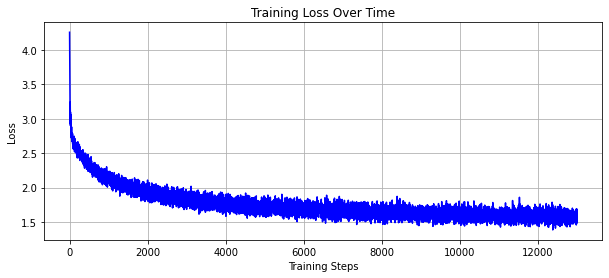

 13%|█▎        | 13078/100000 [13:58<1:32:51, 15.60it/s, Loss=1.59]


KeyboardInterrupt: 

In [6]:

NUM_ITERATIONS = 100000
LEARNING_RATE = 1e-3

# create the optimizer
optimizer = torch.optim.Adam(list(gpt.parameters()), lr=LEARNING_RATE)

# create a mask for the input sequences
with torch.no_grad():
    mask_2d = torch.tril(torch.ones(MAX_LENGTH, MAX_LENGTH)).to(device) # create a lower triangular mask

loss_logs = []

# training loop
with tqdm(total=NUM_ITERATIONS) as pbar:
    iter_ = 0
    while iter_ < NUM_ITERATIONS:

        optimizer.zero_grad()

        # prepare training data
        with torch.no_grad():
            # get a random batch of data
            # batch_x, batch_y : [N, L]
            batch_x, batch_y = get_random_batch(data_token_indices, 
                                                batch_size=BATCH_SIZE, block_size=MAX_LENGTH, 
                                                device=device) # test the function
            
            batch_x_emb = token_embeder(batch_x) # get the token embeddings [N, L, D]

        # forward pass
        logits = gpt.decode(x=batch_x_emb, mask_2d=mask_2d) # [N, L, V] (V = vocabulary size)
        # if iter_ % 10 == 0:
        #     print(torch.argmax(logits[0], dim=-1).cpu().numpy())


        # compute cross-entropy loss
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), batch_y.view(-1), ignore_index=-1)

        if torch.isnan(loss) == False:
            loss.backward()
            optimizer.step()
            pbar.set_postfix({'Loss': loss.item()})
            loss_logs.append(loss.item())
        
        # # Optional logging
        # if iter_ % 100 == 0:
        #     targ_tokens = batch_y[0].cpu().tolist()
        #     print("Target:   ", "".join(tokenizer.get_tokens(targ_tokens)))
        #     pred_tokens = torch.argmax(logits[0], dim=-1).cpu().tolist()
        #     print("Predicted:", "".join(tokenizer.get_tokens(pred_tokens)))
       
        # Refresh plot every 100 steps
        if iter_ % 100 == 0 and iter_ > 0:
            clear_output(wait=True)  # if you're in a notebook
            plt.figure(figsize=(10, 4))
            plt.plot(loss_logs, label='Loss', color='blue')
            plt.xlabel('Training Steps')
            plt.ylabel('Loss')
            plt.title('Training Loss Over Time')
            plt.grid(True)
            plt.show()

        pbar.update(1)
        iter_ += 1



In [ ]:
# Save the GPT model weights
# model_save_path = './shakespeare_gpt_weights.pth'
# torch.save(gpt._orig_mod.state_dict(), model_save_path)
# print(f"Model weights saved to {model_save_path}")


Model weights saved to ./shakespeare_gpt_weights.pth


### Generate

In [22]:

with torch.no_grad():
    context = torch.ones((1, 1), dtype=torch.long, device=device)
    for i in range(60):
        # crop idx to the last block_size tokens
        idx_cond = context[:, -MAX_LENGTH:]
        # get the predictions
        x_emb = token_embeder(idx_cond) # get the token embeddings [N, L, D]
        mask_2d_temp = torch.tril(torch.ones(i+1, i+1)).to(device) # create a lower triangular mask
        logits = gpt.decode(x_emb, mask_2d=mask_2d_temp) # [N, L, V] (V = vocabulary size)
        # focus only on the last time step
        logits = logits[:, -1, :] # becomes (B, C)
        # apply softmax to get probabilities
        probs = F.softmax(logits, dim=-1) # (B, C)
        # sample from the distribution
        idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
        # append sampled index to the running sequence
        context = torch.cat((context, idx_next), dim=1) # (B, T+1)

        generated_tokens = context[0, :].cpu().numpy()
        print(f"\r", "".join(tokenizer.get_tokens(generated_tokens)), end='', flush=True)
    

 <BEGIN>AUSo's hand;beit with she curpent.I tender thee.'RICHIO:And,